<a href="https://colab.research.google.com/github/pughbrennan02-ai/Diamond-Assignment/blob/main/ExtraCredit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install -q requests pillow matplotlib

In [2]:
from io import BytesIO

import matplotlib.pyplot as plt
import requests
import torch
from PIL import Image
from torchvision.models import MobileNet_V2_Weights, mobilenet_v2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('PyTorch version:', torch.__version__)
print('Using device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu130
Using device: cuda
GPU: Tesla T4


In [3]:
weights = MobileNet_V2_Weights.DEFAULT
model = mobilenet_v2(weights=weights).to(device)
model.eval()

preprocess = weights.transforms()
class_names = weights.meta['categories']

print('Model: MobileNetV2')
print('Weights:', weights)
print(f'ImageNet classes: {len(class_names):,}')
print(f'Model parameters: {sum(parameter.numel() for parameter in model.parameters()):,}')

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 205MB/s]


Model: MobileNetV2
Weights: MobileNet_V2_Weights.IMAGENET1K_V2
ImageNet classes: 1,000
Model parameters: 3,504,872


In [4]:
image_urls = {
    'Dog': 'https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg',
    'Cat': 'https://commons.wikimedia.org/wiki/Special:Redirect/file/Cat03.jpg',
    'Banana': 'https://commons.wikimedia.org/wiki/Special:Redirect/file/Banana-Single.jpg',
}

for image_name, image_url in image_urls.items():
    print(f'{image_name}: {image_url}')

Dog: https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg
Cat: https://commons.wikimedia.org/wiki/Special:Redirect/file/Cat03.jpg
Banana: https://commons.wikimedia.org/wiki/Special:Redirect/file/Banana-Single.jpg


In [5]:
def download_image(url):
    headers = {'User-Agent': 'Mozilla/5.0 (educational image-classification notebook)'}
    response = requests.get(url, headers=headers, timeout=60)
    response.raise_for_status()
    return Image.open(BytesIO(response.content)).convert('RGB')

images = {name: download_image(url) for name, url in image_urls.items()}

for name, image in images.items():
    print(f'{name:<8} size={image.size}, mode={image.mode}')

Dog      size=(1546, 1213), mode=RGB
Cat      size=(1600, 1598), mode=RGB
Banana   size=(3030, 2670), mode=RGB


In [6]:
prediction_results = {}

with torch.inference_mode():
    for image_name, image in images.items():
        input_tensor = preprocess(image).unsqueeze(0).to(device)
        logits = model(input_tensor)
        probabilities = torch.softmax(logits[0], dim=0)
        top_probabilities, top_indices = torch.topk(probabilities, k=5)

        prediction_results[image_name] = [
            {
                'class_name': class_names[class_index],
                'confidence': confidence.item(),
            }
            for confidence, class_index in zip(
                top_probabilities.cpu(), top_indices.cpu().tolist()
            )
        ]

In [7]:
for image_name, predictions in prediction_results.items():
    print(f'\n{image_name.upper()} — TOP-5 PREDICTIONS')
    print('-' * 48)
    for rank, prediction in enumerate(predictions, start=1):
        print(
            f"{rank}. {prediction['class_name']:<30} "
            f"{prediction['confidence']:>7.2%}"
        )


DOG — TOP-5 PREDICTIONS
------------------------------------------------
1. Samoyed                         30.91%
2. Pomeranian                       5.10%
3. keeshond                         1.59%
4. white wolf                       1.43%
5. Arctic fox                       1.08%

CAT — TOP-5 PREDICTIONS
------------------------------------------------
1. tiger cat                       12.38%
2. Egyptian cat                     8.31%
3. tabby                            5.07%
4. lynx                             1.86%
5. carton                           0.78%

BANANA — TOP-5 PREDICTIONS
------------------------------------------------
1. banana                          85.88%
2. butternut squash                 0.70%
3. spaghetti squash                 0.54%
4. slug                             0.19%
5. mortar                           0.17%


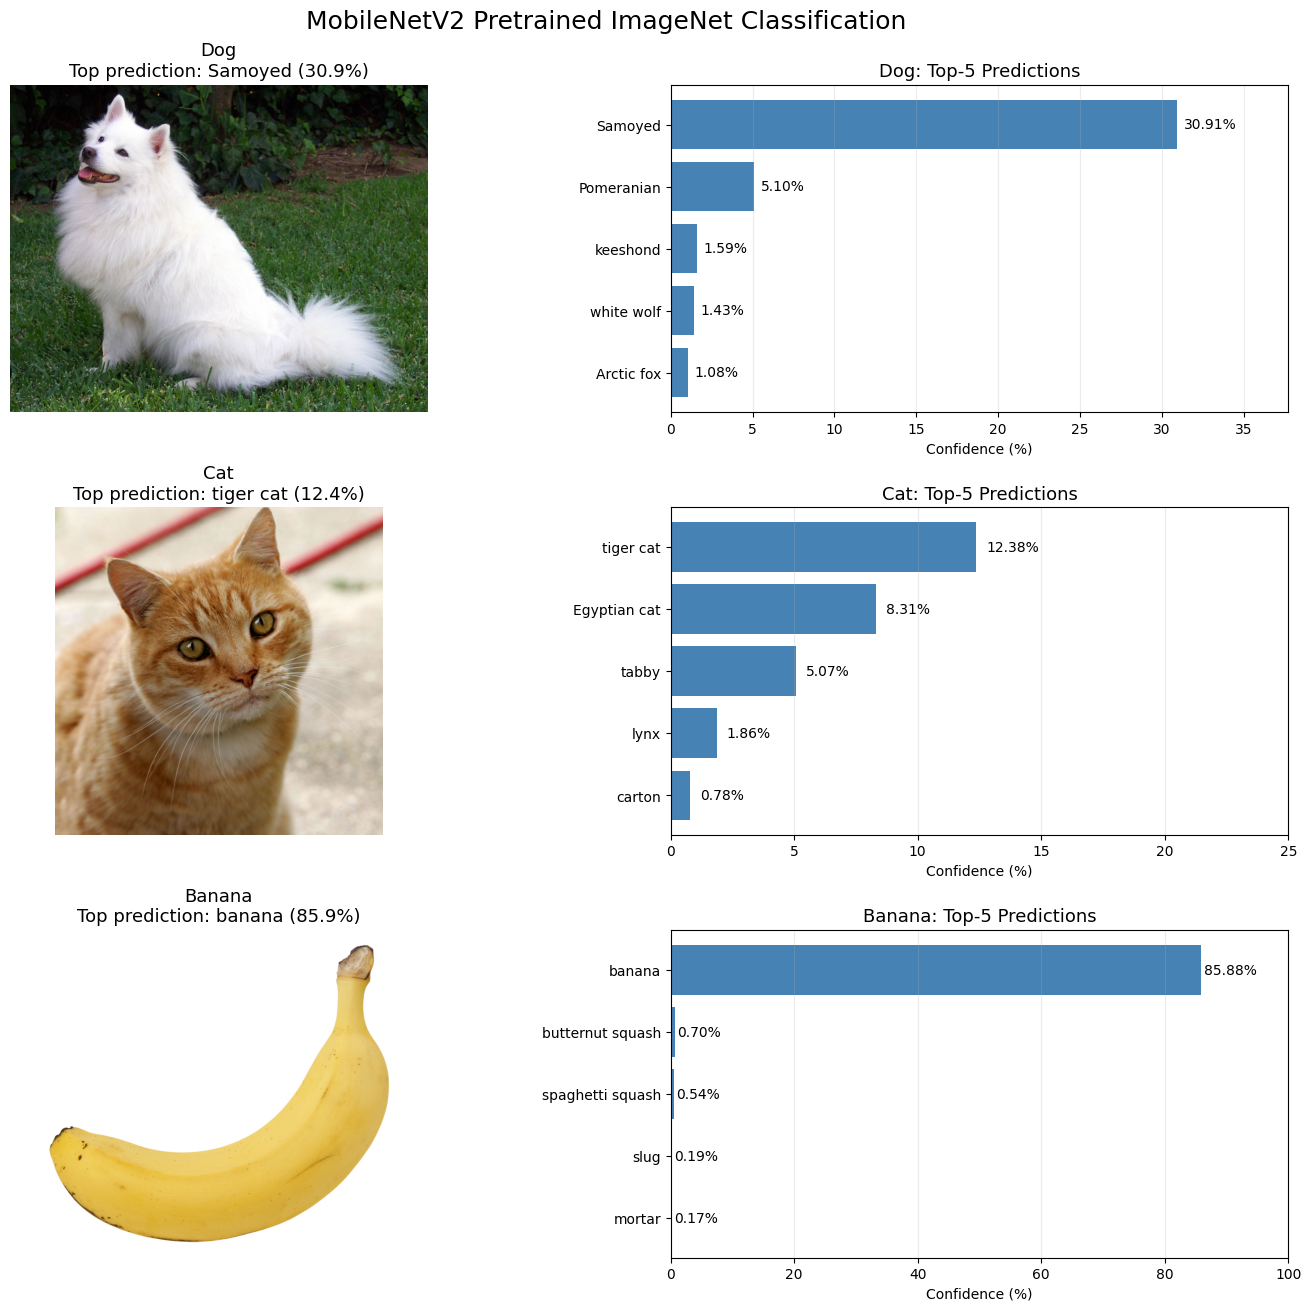

In [8]:
figure, axes = plt.subplots(3, 2, figsize=(14, 13), constrained_layout=True)

for row, (image_name, image) in enumerate(images.items()):
    predictions = prediction_results[image_name]
    labels = [prediction['class_name'] for prediction in predictions]
    confidence_percentages = [
        prediction['confidence'] * 100 for prediction in predictions
    ]

    image_axis = axes[row, 0]
    image_axis.imshow(image)
    image_axis.set_title(
        f"{image_name}\nTop prediction: {labels[0]} "
        f"({confidence_percentages[0]:.1f}%)",
        fontsize=13,
    )
    image_axis.axis('off')

    prediction_axis = axes[row, 1]
    bars = prediction_axis.barh(
        labels, confidence_percentages, color='steelblue'
    )
    prediction_axis.invert_yaxis()
    prediction_axis.set_title(f'{image_name}: Top-5 Predictions', fontsize=13)
    prediction_axis.set_xlabel('Confidence (%)')
    prediction_axis.set_xlim(
        0, min(100, max(25, confidence_percentages[0] * 1.22))
    )
    prediction_axis.grid(axis='x', alpha=0.25)

    for bar, confidence in zip(bars, confidence_percentages):
        prediction_axis.text(
            confidence + 0.4,
            bar.get_y() + bar.get_height() / 2,
            f'{confidence:.2f}%',
            va='center',
            fontsize=10,
        )

figure.suptitle(
    'MobileNetV2 Pretrained ImageNet Classification',
    fontsize=18,
)
plt.savefig('mobilenetv2_top5_predictions.png', dpi=180, bbox_inches='tight')
plt.show()